# S2_gen_data_optimized_cp_v4

This notebook is a runnable check-oriented version of `S2_gen_data_optimized_cp_v2.ipynb`.

It keeps the same model logic and parameter settings, while organizing the workflow so you can run it top-to-bottom for:

- environment/path checking
- data generation
- original vs optimized benchmark
- visualization
- optional large dataset generation
- fast-RT diagnostics

Recommended run order: execute all cells from top to bottom.


## Run Notes

1. Run the notebook from top to bottom.
2. `RUN_LARGE_DATASET` is `False` by default. Keep it off until benchmark and diagnostics look normal.
3. The optimized parallel path uses thread-based joblib to avoid the Windows Unicode multiprocessing error.
4. Output files are written into project-local `2_Data` and `3_Figures` folders.


# S2: Simulated Data Generation using Drift Diffusion Model

## Purpose
Generate simulated behavioral data using an evidence accumulation framework. 

This scripts serves one purpose:
- (1) Generate a large dataset for study 2, which will quantify the model's prediction.

This script include the original algorithm created by Jiahui Wen, and improved algorithm (parallel processing) by HCP (aided by AI agents). The improvement include:
- (1) More streamlined coding style (aided with ai agents)
- (2) Vectorized data generation (aided with ai agents)
- (3) Added noise to parameter *a* (an issue identified by re-analyzing the S2 results)

## Metadata
- **Random seed**: 42 (set at notebook start)
- **Output file**: 260220.csv (random-space synthetic dataset)
- **Last modified**: 2026-02-15

## Enviroment
This script should be run within the docker container of [`dockerHDDM`](https://hub.docker.com/r/hcp4715/hddm).

In [3]:
# Check current working directory and candidate output locations
from pathlib import Path

cwd = Path.cwd()
print('Current working directory:', cwd)
print('Exists ./work/Study2:', (cwd / 'work' / 'Study2').exists())
print('Notebook directory candidates:')
for p in [cwd, cwd.parent, cwd.parent.parent]:
    print(' -', p)


ls: cannot access './work/Study2': No such file or directory


In [1]:
# Optional environment summary (pure Python fallback, no notebook magics)
try:
    from watermark import watermark
    print(watermark())
except Exception as exc:
    print('watermark not available, skipping optional version banner.')
    print('Reason:', exc)


watermark not available, skipping optional version banner.
Reason: No module named 'watermark'


In [2]:
# =============================================================================
# IMPORTS AND ENVIRONMENT
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import norm
import time
import sys
import matplotlib.pyplot as plt

# Print version information for reproducibility
print("Environment versions:")
print(f"  Python: {sys.version.split()[0]}")
print(f"  NumPy: {np.__version__}")
print(f"  SciPy: {__import__('scipy').__version__}")
print(f"  Pandas: {pd.__version__}")


Environment versions:
  Python: 3.13.1
  NumPy: 2.2.0
  SciPy: 1.14.1
  Pandas: 2.2.3


In [4]:
# =============================================================================
# PATHS AND RUNTIME FLAGS
# =============================================================================
PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path(r'D:/GitHub_programe/GitHub/Guassion-Process-Experiment-Design'),
]

BASE_DIR = None
for candidate in PROJECT_ROOT_CANDIDATES:
    if (candidate / '1_Code' / 'Python_for_Generate').exists():
        BASE_DIR = candidate
        break

if BASE_DIR is None:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / '2_Data' / 'Generate_Data' / 'S2_gen_data_optimized_cp_v4'
OUTPUT_DIR = BASE_DIR / '3_Figures' / 'S2_gen_data_optimized_cp_v4'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('BASE_DIR:', BASE_DIR)
print('DATA_DIR:', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

# Execution controls for notebook sections
RUN_BENCHMARK = True
RUN_VALIDATION_PLOTS = True
RUN_LARGE_DATASET = False

# Benchmark and large-run defaults
BENCHMARK_SUBJECTS = 1000
BENCHMARK_TRIALS = 260
LARGE_OUTPUT_FILE = DATA_DIR / '260220.csv'


BASE_DIR: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design
DATA_DIR: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\S2_gen_data_optimized_cp_v4
OUTPUT_DIR: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\S2_gen_data_optimized_cp_v4


In [5]:
# =============================================================================
# CONFIGURATION - All parameters in one place for reproducibility
# =============================================================================

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# =============================================================================
# MODEL PARAMETERS
# =============================================================================
# Drift rate modifiers
ALPHA1 = 1.5    # Self condition: increases drift rate
ALPHA2 = -0.4   # Stranger condition: smaller effect

# Boundary modifiers
BETA1 = 0.2     # High W (>600): increases boundary
BETA2 = 0       # Low W (<=600): smaller effect

# Sigmoid parameters
GAMMA = 0.1     # Sigmoid steepness for P effect

# Non-decision time
T0 = 0.2        # Seconds

# Simulation settings
DELTA_T = 0.001  # Time step in seconds (1ms)

# Between-subject variability for boundary a
A_CV = 0.15  # Coefficient of variation (15%)

# Condition mapping
CONDITIONS = {0: 'stranger', 1: 'self'}

# Experimental conditions: (P, T, W)



In [6]:
# =============================================================================
# MODEL FUNCTIONS
# =============================================================================

def k_P_func(P, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    """Sigmoid function for k (P effect) varying with practice."""
    return k_min + (k_max - k_min) / (1 + np.exp(-gamma * (P - P0)))


def v_P_func(P, P1=4, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    """Sigmoid function for P effect on drift rate."""
    k = k_P_func(P, k_min, k_max, gamma, P0)
    return 1 / (1 + np.exp(-k * (P - P1)))


def compute_v(T, P, condition_key):
    """Compute drift rate v based on T, P, and condition."""
    T_0 = 100
    k_T = 0.01

    v_T = 1 / (1 + np.exp(-k_T * (T - T_0)))
    v_P = v_P_func(P=P, P1=4, k_min=0.01, k_max=0.15, gamma=GAMMA, P0=32)
    v_0 = v_T * v_P * 3

    # Apply condition-specific modifier
    if condition_key == 1:  # self
        v_1 = v_0 * (1 + ALPHA1)
    else:  # stranger
        v_1 = v_0 * (1 + ALPHA2)
    
    return v_1


def compute_a(M):
    """Compute boundary threshold a based on M = T + W."""
    k = 0.01
    M_0 = 600

    a_0 = 1 / (1 + np.exp(-k * (M - M_0))) * 3

    if M > 600:
        a_1 = a_0 * (1 + BETA1)
    else:
        a_1 = a_0 * (1 + BETA2)

    return max(a_1, 0.3)


In [7]:
# ==============================================================================
# VECTORIZING SIMULATION FUNCTIONS
# ==============================================================================

def simulate_single_trial_vectorized(v, a, t0, max_time_steps, delta_t):
    """
    Simulate a single trial using vectorized noise generation.
    More efficient than generating noise one at a time.
    """
    # Pre-generate all noise for this trial at once
    noise = norm.rvs(loc=0, scale=1, size=max_time_steps) * np.sqrt(delta_t)
    
    # Compute drift component (constant for this trial)
    drift = v * delta_t
    
    # Cumulative evidence
    evidence = a / 2 + np.cumsum(drift + noise)
    
    # Find first boundary crossing
    upper_crossing = np.where(evidence >= a)[0]
    lower_crossing = np.where(evidence <= 0)[0]
    
    if len(upper_crossing) > 0 and len(lower_crossing) > 0:
        # First crossing determines the outcome
        if upper_crossing[0] < lower_crossing[0]:
            return (upper_crossing[0] + 1) * delta_t + t0, 1
        else:
            return (lower_crossing[0] + 1) * delta_t + t0, 2
    elif len(upper_crossing) > 0:
        return (upper_crossing[0] + 1) * delta_t + t0, 1
    elif len(lower_crossing) > 0:
        return (lower_crossing[0] + 1) * delta_t + t0, 2
    else:
        # No decision within time limit
        return max_time_steps * delta_t + t0, 0


In [8]:
# =============================================================================
# ADDITIONAL FUNCTION: Random P, T, W generation
# =============================================================================

def generate_data_random_params(num_subjects, num_trials):
    """
    Generate data with random P, T, W for each subject.
    This is the original '250430.csv' generation function.
    """
    all_data = []
    
    for subject in range(num_subjects):
        # Random P, T, W for each subject
        T = np.random.randint(10, 600)
        P = np.random.randint(0, 150)
        W = np.random.randint(200, 1500)
        M = T + W
        
        # Compute boundary with between-subject variability
        a_base = compute_a(M)
        a = np.random.normal(a_base, a_base * A_CV)
        a = max(a, CONFIG['A_FLOOR'] if 'CONFIG' in globals() else 0.3)
        
        # Trials per condition
        trials_per_condition = num_trials // 2
        if num_trials % 2 != 0:
            trials_per_condition += 1
        
        max_time = (W + T - T0) * 0.001 + 0.001
        max_time_steps = int(max_time / DELTA_T)
        
        for condition_key in range(2):
            label = CONDITIONS[condition_key]
            
            for trial in range(trials_per_condition):
                v = compute_v(T, P, condition_key)
                v = np.random.normal(v, 1)
                
                decision_time, response = simulate_single_trial_vectorized(
                    v, a, T0, max_time_steps, DELTA_T
                )
                
                if response > 0 and decision_time < max_time:
                    all_data.append({
                        'subjectID': subject + 1,
                        'trialID': trial + 1,
                        'T': T, 'P': P, 'W': W,
                        'Label': label,
                        'v': v, 'a': a,
                        'RT': decision_time,
                        'response': response
                    })
    
    return pd.DataFrame(all_data)

In [9]:
# =============================================================================
# OPTIMIZED: Batch Vectorization + Parallel Processing
# =============================================================================

from joblib import Parallel, delayed

def compute_a_vectorized(M_batch, a_cv=A_CV):
    """Vectorized boundary computation with between-subject variability."""
    k, M_0 = 0.01, 600
    a_0 = 1 / (1 + np.exp(-k * (M_batch - M_0))) * 3
    beta = np.where(M_batch > 600, 1 + BETA1, 1 + BETA2)
    a = a_0 * beta
    if a_cv is not None and a_cv > 0:
        a = a * np.random.normal(1, a_cv, len(M_batch))
    # Handle negative values
    a = np.maximum(a, CONFIG['A_FLOOR'] if 'CONFIG' in globals() else 0.3)
    return a

def generate_batch_vectorized(subjects_batch, num_trials, base_seed):
    """Process a batch of subjects with vectorized parameter calculations."""
    np.random.seed(base_seed)
    
    n_subjects = len(subjects_batch)
    trials_per_condition = num_trials // 2
    if num_trials % 2 != 0:
        trials_per_condition += 1
    
    # Pre-generate P, T, W for all subjects in batch (vectorized)
    T_batch = np.random.randint(10, 600, n_subjects)
    P_batch = np.random.randint(0, 150, n_subjects)
    W_batch = np.random.randint(200, 1500, n_subjects)
    M_batch = T_batch + W_batch
    
    # Vectorized boundary computation with between-subject variability
    a_batch = compute_a_vectorized(M_batch, a_cv=A_CV)
    
    # Pre-compute max_time for each subject
    max_times = (W_batch + T_batch - T0) * 0.001 + 0.001
    max_time_steps = (max_times / DELTA_T).astype(int)
    
    # Generate trials for each subject
    all_results = []
    
    for i, subject in enumerate(subjects_batch):
        T, P, W, a, max_time, max_ts = (
            T_batch[i], P_batch[i], W_batch[i], a_batch[i],
            max_times[i], max_time_steps[i]
        )
        
        # Process both conditions
        for condition_key in range(2):
            label = CONDITIONS[condition_key]
            
            for trial in range(trials_per_condition):
                # Compute drift rate
                v = compute_v(T, P, condition_key)
                v = np.random.normal(v, 1)
                
                # Simulate trial
                decision_time, response = simulate_single_trial_vectorized(
                    v, a, T0, max_ts, DELTA_T
                )
                
                # Only keep valid trials
                if response > 0 and decision_time < max_time:
                    all_results.append({
                        'subjectID': subject + 1,
                        'trialID': trial + 1,
                        'T': T, 'P': P, 'W': W,
                        'Label': label,
                        'v': v, 'a': a,
                        'RT': decision_time,
                        'response': response
                    })
    
    return pd.DataFrame(all_results)

def generate_data_random_params_optimized(num_subjects, num_trials, batch_size=100, n_jobs=-2):
    """
    Hybrid: Batch vectorization + Parallel processing.
    
    Parameters:
    - num_subjects: Number of subjects to generate
    - num_trials: Number of trials per subject
    - batch_size: Subjects per batch (default 50)
    - n_jobs: Number of parallel jobs (-2 = all cores except 1)
    """
    # Split subjects into batches
    subjects = np.arange(num_subjects)
    n_batches = (num_subjects + batch_size - 1) // batch_size
    batches = np.array_split(subjects, n_batches)
    
    print(f"Processing {num_subjects} subjects in {n_batches} batches (size={batch_size})...")
    
    # Process batches in parallel
    results = Parallel(n_jobs=n_jobs, verbose=1, prefer="threads")(
        delayed(generate_batch_vectorized)(batch, num_trials, SEED + i * 1000)
        for i, batch in enumerate(batches)
    )
    
    # Combine results
    df = pd.concat(results, ignore_index=True)
    return df


In [10]:
# =============================================================================
# VALIDATION: Compare Original vs Optimized
# =============================================================================

if RUN_BENCHMARK:
    print("=" * 60)
    print(f"VALIDATION: Original vs Optimized ({BENCHMARK_SUBJECTS} subjects)")
    print("=" * 60)

    np.random.seed(SEED)
    print("\n1. Original function:")
    start = time.time()
    df_original = generate_data_random_params(BENCHMARK_SUBJECTS, BENCHMARK_TRIALS)
    orig_time = time.time() - start
    print(f"   Time: {orig_time:.2f}s")
    print(f"   Rows: {len(df_original)}, Subjects: {df_original['subjectID'].nunique()}")
    print(f"   Mean RT: {df_original['RT'].mean():.4f}s")
    print(f"   Accuracy: {(df_original['response'] == 1).mean():.4f}")
    print(f"   Mean a: {df_original['a'].mean():.4f} | Std a: {df_original['a'].std():.4f}")
    print(f"   Mean v: {df_original['v'].mean():.4f} | Std v: {df_original['v'].std():.4f}")

    np.random.seed(SEED)
    print("\n2. Optimized function (batch_size=100):")
    start = time.time()
    df_optimized = generate_data_random_params_optimized(
        BENCHMARK_SUBJECTS, BENCHMARK_TRIALS, batch_size=100, n_jobs=-1
    )
    opt_time = time.time() - start
    print(f"   Time: {opt_time:.2f}s")
    print(f"   Rows: {len(df_optimized)}, Subjects: {df_optimized['subjectID'].nunique()}")
    print(f"   Mean RT: {df_optimized['RT'].mean():.4f}s")
    print(f"   Accuracy: {(df_optimized['response'] == 1).mean():.4f}")
    print(f"   Mean a: {df_optimized['a'].mean():.4f} | Std a: {df_optimized['a'].std():.4f}")
    print(f"   Mean v: {df_optimized['v'].mean():.4f} | Std v: {df_optimized['v'].std():.4f}")

    print("\n3. Parameter differences (optimized - original):")
    print(f"   Delta mean a: {df_optimized['a'].mean() - df_original['a'].mean():.4f}")
    print(f"   Delta std a:  {df_optimized['a'].std() - df_original['a'].std():.4f}")
    print(f"   Delta mean v: {df_optimized['v'].mean() - df_original['v'].mean():.4f}")
    print(f"   Delta std v:  {df_optimized['v'].std() - df_original['v'].std():.4f}")
    print(f"\nSpeedup: {orig_time/opt_time:.2f}x")
else:
    print("Benchmark section skipped (RUN_BENCHMARK=False).")

VALIDATION: Original vs Optimized (1000 subjects)

1. Original function:
   Time: 23.52s
   Rows: 193027, Subjects: 1000
   Mean RT: 0.5966s
   Accuracy: 0.9509
   Mean a: 3.0980 | Std a: 1.0423
   Mean v: 4.1866 | Std v: 2.5162

2. Optimized function (batch_size=100):
Processing 1000 subjects in 10 batches (size=100)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:  1.0min remaining:  1.5min


   Time: 61.40s
   Rows: 191329, Subjects: 1000
   Mean RT: 0.5887s
   Accuracy: 0.9525
   Mean a: 3.1039 | Std a: 1.0621
   Mean v: 4.2709 | Std v: 2.5288

3. Parameter differences (optimized - original):
   Delta mean a: 0.0059
   Delta std a:  0.0198
   Delta mean v: 0.0843
   Delta std v:  0.0127

Speedup: 0.38x


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  1.0min finished


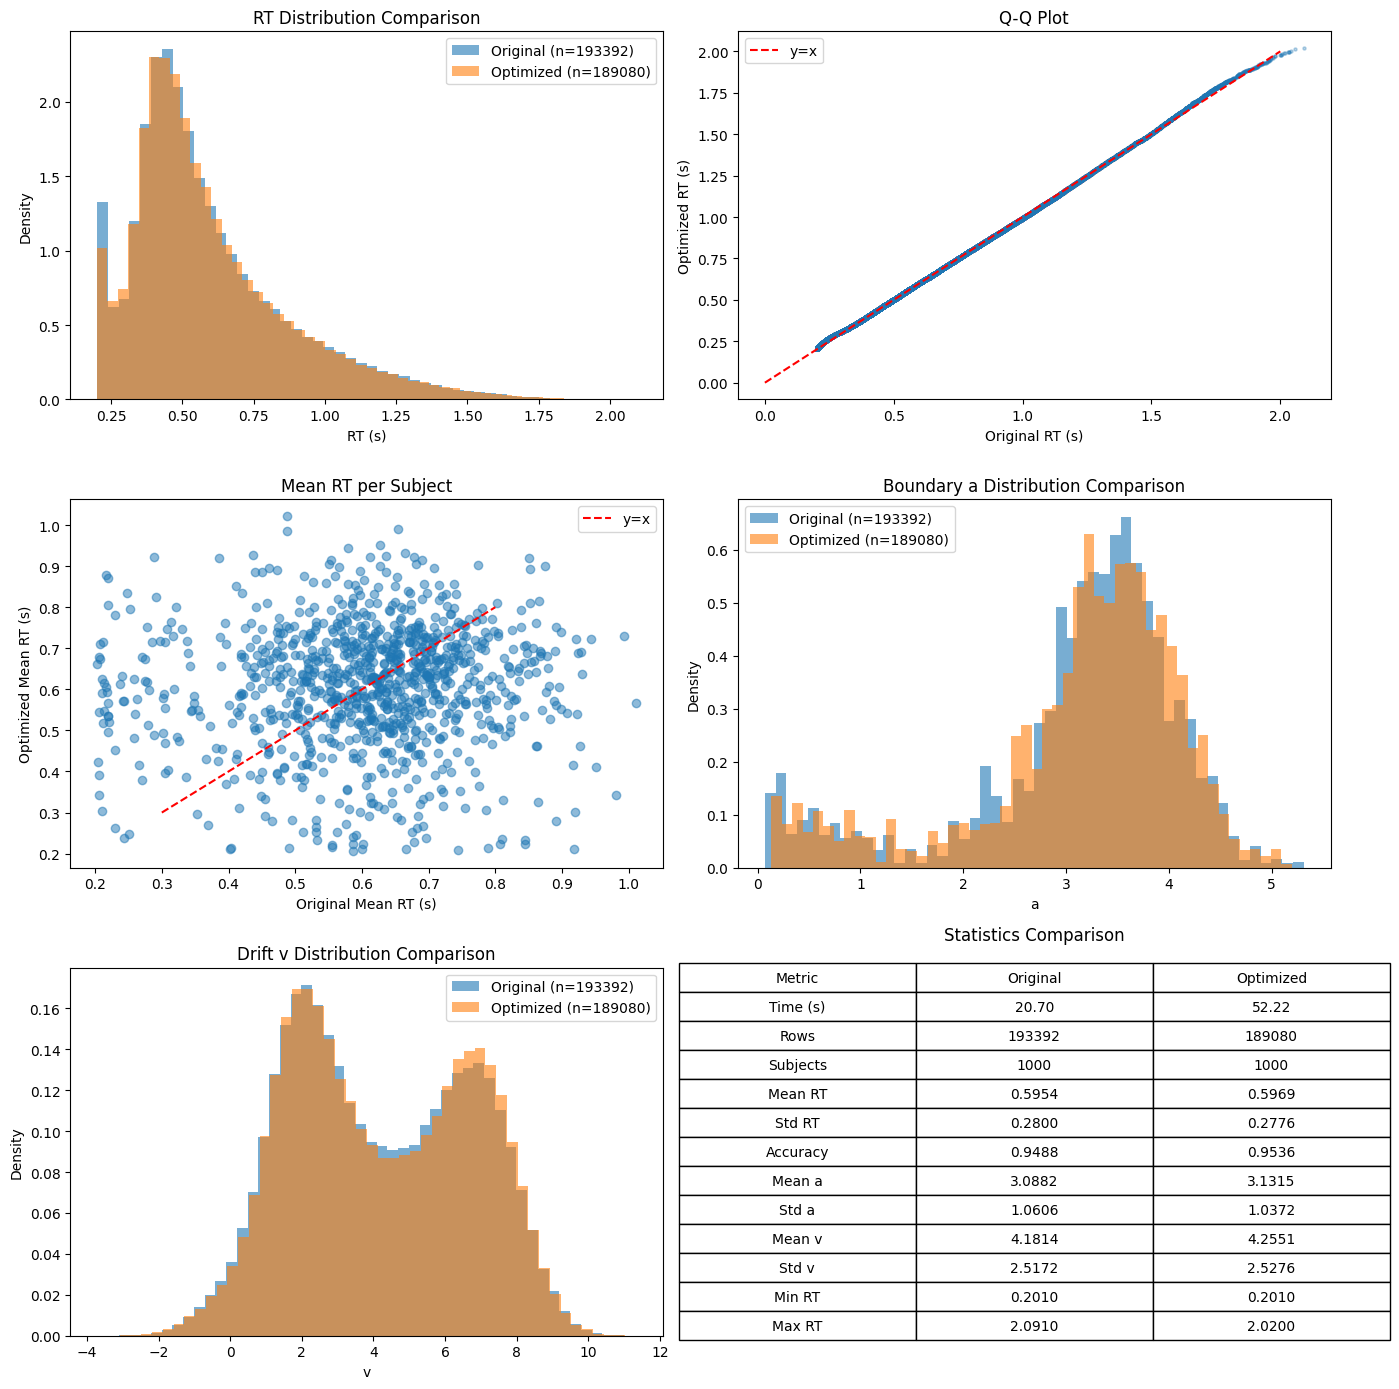


Plot saved to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\S2_gen_data_optimized_cp_v3\validation_comparison.png
Benchmark data kept in memory for diagnostics.


In [26]:
# =============================================================================
# VISUALIZATION: Detailed Comparison
# =============================================================================
if RUN_VALIDATION_PLOTS and RUN_BENCHMARK:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))

    ax1 = axes[0, 0]
    ax1.hist(df_original['RT'], bins=50, alpha=0.6, label=f'Original (n={len(df_original)})', density=True)
    ax1.hist(df_optimized['RT'], bins=50, alpha=0.6, label=f'Optimized (n={len(df_optimized)})', density=True)
    ax1.set_xlabel('RT (s)')
    ax1.set_ylabel('Density')
    ax1.set_title('RT Distribution Comparison')
    ax1.legend()

    ax2 = axes[0, 1]
    min_n = min(len(df_original), len(df_optimized))
    rt_orig = np.sort(df_original['RT'].sample(min_n, random_state=SEED).values)
    rt_opt = np.sort(df_optimized['RT'].sample(min_n, random_state=SEED).values)
    ax2.scatter(rt_orig, rt_opt, alpha=0.3, s=5)
    ax2.plot([0, 2], [0, 2], 'r--', label='y=x')
    ax2.set_xlabel('Original RT (s)')
    ax2.set_ylabel('Optimized RT (s)')
    ax2.set_title('Q-Q Plot')
    ax2.legend()

    ax3 = axes[1, 0]
    orig_subject_means = df_original.groupby('subjectID')['RT'].mean()
    opt_subject_means = df_optimized.groupby('subjectID')['RT'].mean()
    ax3.scatter(orig_subject_means, opt_subject_means, alpha=0.5)
    ax3.plot([0.3, 0.8], [0.3, 0.8], 'r--', label='y=x')
    ax3.set_xlabel('Original Mean RT (s)')
    ax3.set_ylabel('Optimized Mean RT (s)')
    ax3.set_title('Mean RT per Subject')
    ax3.legend()

    ax4 = axes[1, 1]
    ax4.hist(df_original['a'], bins=50, alpha=0.6, label=f'Original (n={len(df_original)})', density=True)
    ax4.hist(df_optimized['a'], bins=50, alpha=0.6, label=f'Optimized (n={len(df_optimized)})', density=True)
    ax4.set_xlabel('a')
    ax4.set_ylabel('Density')
    ax4.set_title('Boundary a Distribution Comparison')
    ax4.legend()

    ax5 = axes[2, 0]
    ax5.hist(df_original['v'], bins=50, alpha=0.6, label=f'Original (n={len(df_original)})', density=True)
    ax5.hist(df_optimized['v'], bins=50, alpha=0.6, label=f'Optimized (n={len(df_optimized)})', density=True)
    ax5.set_xlabel('v')
    ax5.set_ylabel('Density')
    ax5.set_title('Drift v Distribution Comparison')
    ax5.legend()

    ax6 = axes[2, 1]
    ax6.axis('off')
    stats_data = {
        'Metric': ['Time (s)', 'Rows', 'Subjects', 'Mean RT', 'Std RT', 'Accuracy', 'Mean a', 'Std a', 'Mean v', 'Std v', 'Min RT', 'Max RT'],
        'Original': [
            f'{orig_time:.2f}', f'{len(df_original)}', f'{df_original["subjectID"].nunique()}',
            f'{df_original["RT"].mean():.4f}', f'{df_original["RT"].std():.4f}',
            f'{(df_original["response"] == 1).mean():.4f}', f'{df_original["a"].mean():.4f}',
            f'{df_original["a"].std():.4f}', f'{df_original["v"].mean():.4f}',
            f'{df_original["v"].std():.4f}', f'{df_original["RT"].min():.4f}',
            f'{df_original["RT"].max():.4f}'
        ],
        'Optimized': [
            f'{opt_time:.2f}', f'{len(df_optimized)}', f'{df_optimized["subjectID"].nunique()}',
            f'{df_optimized["RT"].mean():.4f}', f'{df_optimized["RT"].std():.4f}',
            f'{(df_optimized["response"] == 1).mean():.4f}', f'{df_optimized["a"].mean():.4f}',
            f'{df_optimized["a"].std():.4f}', f'{df_optimized["v"].mean():.4f}',
            f'{df_optimized["v"].std():.4f}', f'{df_optimized["RT"].min():.4f}',
            f'{df_optimized["RT"].max():.4f}'
        ]
    }
    stats_df = pd.DataFrame(stats_data)
    table = ax6.table(cellText=stats_df.values, colLabels=stats_df.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    ax6.set_title('Statistics Comparison', pad=20)

    plt.tight_layout()
    plot_path = OUTPUT_DIR / "validation_comparison.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nPlot saved to: {plot_path}")

    # Keep benchmark dataframes for downstream diagnostics
    # import gc
    # gc.collect()
    print("Benchmark data kept in memory for diagnostics.")
else:
    print("Validation plots skipped (RUN_VALIDATION_PLOTS=False or RUN_BENCHMARK=False).")


In [15]:
# =============================================================================
# GENERATE LARGE DATASET (250430.csv equivalent)
# =============================================================================

# Generate large dataset with random P, T, W for model fitting
NUM_SUBJECTS_LARGE = 2000  # ~ 4.42 Gb
NUM_TRIALS_LARGE = 260

if RUN_LARGE_DATASET:
    print(f"\nGenerating large dataset: {NUM_SUBJECTS_LARGE} subjects...")
    large_start = time.time()
    np.random.seed(SEED)

    df_large = generate_data_random_params_optimized(
        NUM_SUBJECTS_LARGE, NUM_TRIALS_LARGE, batch_size=100, n_jobs=-1
    )
    df_large.to_csv(LARGE_OUTPUT_FILE, index=False)

    large_time = time.time() - large_start
    print(f"{LARGE_OUTPUT_FILE}: {len(df_large)} rows, {df_large['subjectID'].nunique()} subjects")
    print(f"Time: {large_time:.2f}s")
else:
    print("Large dataset section skipped (RUN_LARGE_DATASET=False).")

Large dataset section skipped (RUN_LARGE_DATASET=False).


In [11]:
# Pure Python package summary
packages = {
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'scipy': __import__('scipy').__version__,
    'matplotlib': plt.matplotlib.__version__,
}
for name, version in packages.items():
    print(f'{name}: {version}')


numpy: 2.2.0
pandas: 2.2.3
scipy: 1.14.1
matplotlib: 3.10.0


## DDM Parameter Summary

This version adds a temporary lower bound for boundary separation: `a >= 0.3`.

### How `v` is computed

1. Practice effect slope:
`k(P) = k_min + (k_max - k_min) / (1 + exp(-gamma * (P - P0)))`

2. Practice contribution to drift:
`v_P = 1 / (1 + exp(-k(P) * (P - P1)))`

3. Preview-time contribution to drift:
`v_T = 1 / (1 + exp(-k_T * (T - T0_center)))`

4. Baseline drift:
`v_0 = v_T * v_P * 3`

5. Condition-specific drift:
- self: `v = v_0 * (1 + ALPHA1)`
- stranger: `v = v_0 * (1 + ALPHA2)`

6. Trial-level drift noise:
`v_trial ~ Normal(v, 1)`

### How `a` is computed

1. Define `M = T + W`.

2. Baseline boundary:
`a_0 = 1 / (1 + exp(-k_M * (M - M0))) * 3`

3. Piecewise boundary adjustment:
- if `M > 600`: `a_1 = a_0 * (1 + BETA1)`
- else: `a_1 = a_0 * (1 + BETA2)`

4. In this v4 notebook, impose a temporary floor:
`a = max(a_1, 0.3)`

5. Subject-level variability (optimized path):
`a_subject = a * Normal(1, A_CV)` and then clipped again to stay at or above `0.3`.

### Why this trial change matters

In earlier results, some PTW combinations produced extremely small `a` values (for example near `0.13` to `0.20`), which made boundary crossing happen almost immediately after `t0 = 0.2`. The temporary floor is a first-pass check to see whether the abnormal left-tail cluster is mainly driven by too-small boundary values.


Diagnosing dataset: df_optimized
Rows: 191,329

=== Overall fast RT summary ===
Fast RT threshold: 0.250 s
T0 reference: 0.200 s
Fast RT count: 9,264
Fast RT proportion: 4.8419%
Very fast RT (< 0.23s) proportion: 2.9530%

=== Label summary ===
      Label       n   mean_rt  median_rt  fast_rate  very_fast_rate    mean_v  \
0      self  122770  0.494490      0.462   0.042030        0.025079  5.703494   
1  stranger   68559  0.757449      0.728   0.059861        0.037501  1.705469   

     mean_a  
0  3.176844  
1  2.973322  

=== Top 20 PTW × Label combinations with highest fast RT rate ===
       T    P    W     Label    n   mean_rt  median_rt  fast_rate    mean_v  \
94    34   89  203      self  101  0.216990     0.2160   1.000000  2.389992   
95    34   89  203  stranger  103  0.217515     0.2130   1.000000  0.525740   
197   65   61  289  stranger  130  0.224254     0.2170   0.930769  0.861373   
365  113   56  203  stranger  130  0.225531     0.2200   0.915385  1.139862   
130   42

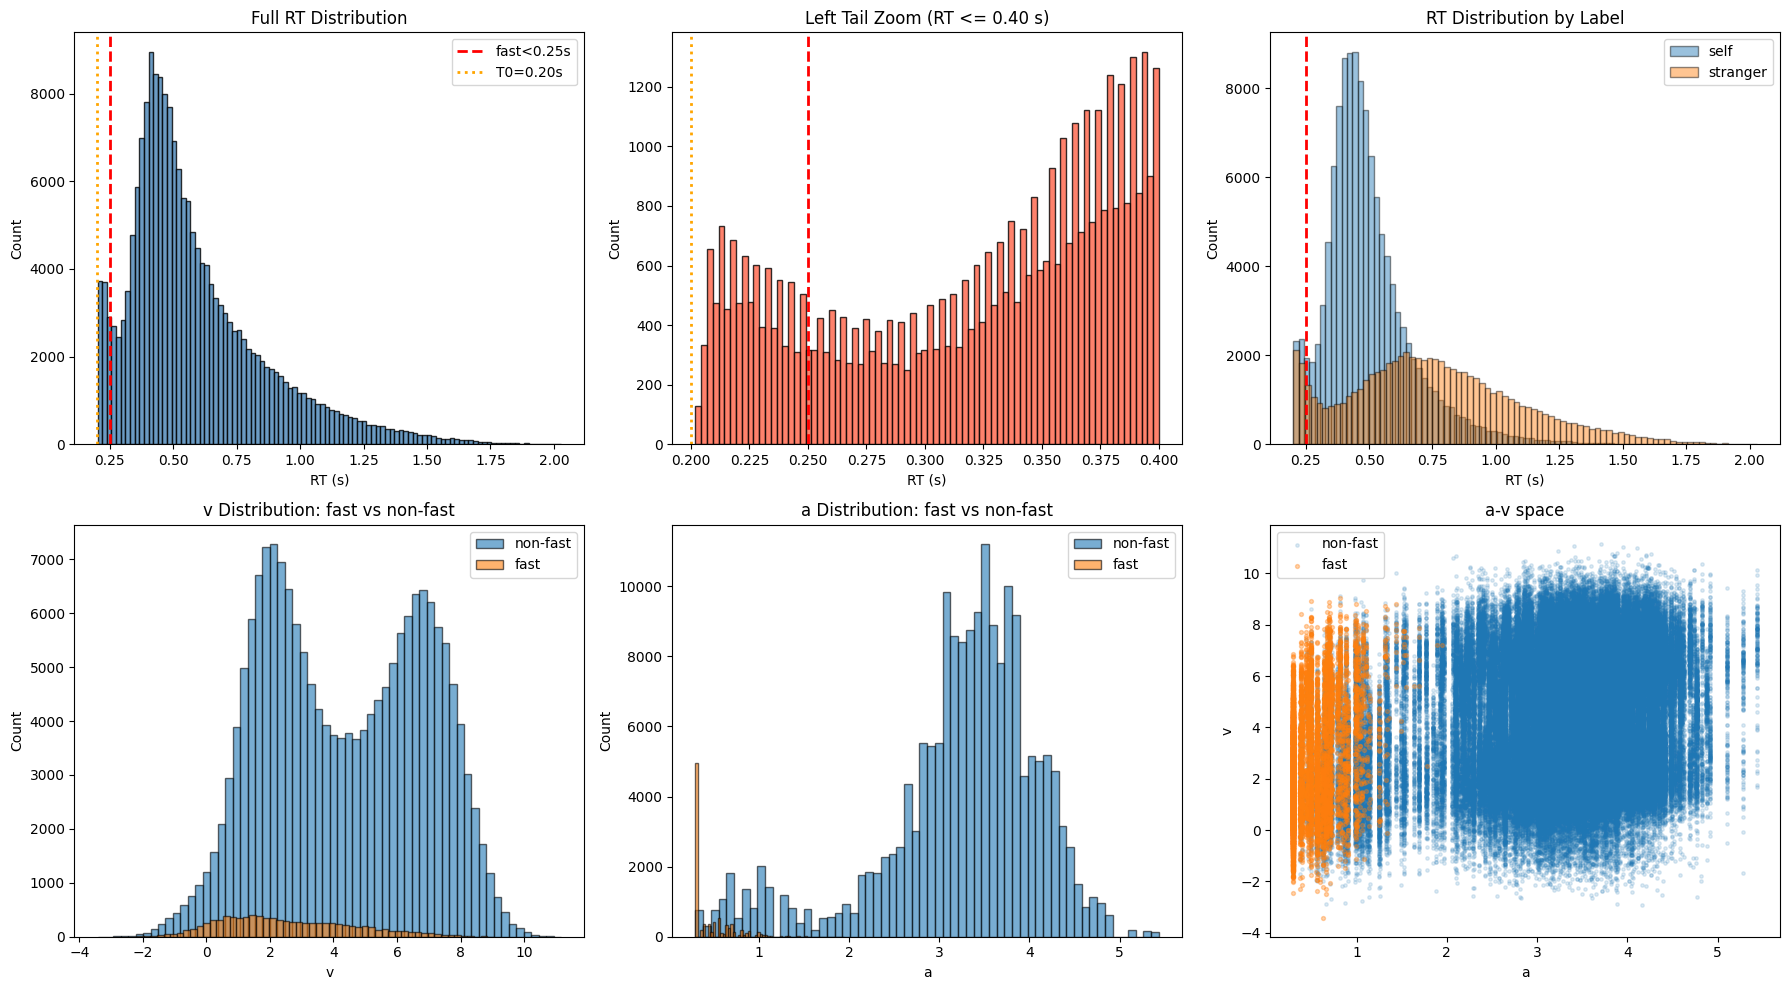

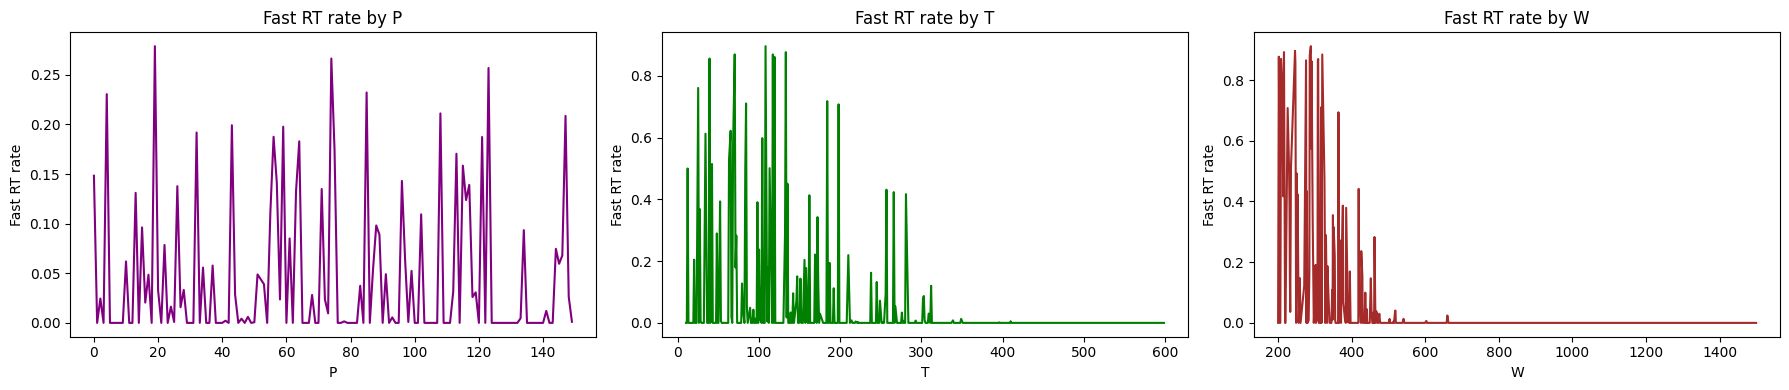


=== Top 15 risky PTW combinations ===
       P    T    W    n  fast_rate   mean_rt    mean_v  mean_a
558   89   34  203  204   1.000000  0.217255  1.448728     0.3
379   61   65  289  260   0.911538  0.223869  1.986914     0.3
142   26   42  235  253   0.905138  0.224881  1.399658     0.3
343   56  113  203  259   0.899614  0.224795  2.612942     0.3
760  115  135  203  260   0.896154  0.224815  2.703862     0.3
981  147  108  246  260   0.896154  0.225388  2.445019     0.3
466   74   68  216  250   0.892000  0.224404  1.905631     0.3
441   71   12  320  259   0.884170  0.226328  1.520061     0.3
367   59   27  349  260   0.880769  0.226342  1.454865     0.3
350   57   25  286  260   0.880769  0.226523  1.487469     0.3
178   32  133  202  260   0.876923  0.225350  2.443518     0.3
403   64  104  231  260   0.876923  0.226296  2.386071     0.3
106   19   70  208  253   0.869565  0.224743  1.344380     0.3
662  102  117  309  260   0.869231  0.225823  2.525498     0.3
18     4  162  2

In [12]:
# =============================================================================
# DIAGNOSIS: Fast RT cluster (< 0.25 s)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------------------------
# 0. Choose dataset to diagnose
# Priority:
#   1) df_optimized
#   2) df_original
#   3) df_large
#   4) load from csv if available
# ---------------------------------------------------------------------------
df_diag = None
diag_name = None

if 'df_optimized' in globals():
    df_diag = df_optimized.copy()
    diag_name = 'df_optimized'
elif 'df_original' in globals():
    df_diag = df_original.copy()
    diag_name = 'df_original'
elif 'df_large' in globals():
    df_diag = df_large.copy()
    diag_name = 'df_large'
else:
    candidate_paths = []

    if 'LARGE_OUTPUT_FILE' in globals():
        candidate_paths.append(Path(LARGE_OUTPUT_FILE))

    if 'DATA_DIR' in globals():
        candidate_paths.extend([
            Path(DATA_DIR) / '260220.csv',
            Path(DATA_DIR) / 'df_optimized.csv',
            Path(DATA_DIR) / 'df_original.csv',
        ])

    for p in candidate_paths:
        if p.exists():
            try:
                df_diag = pd.read_csv(p)
                diag_name = f'loaded_from_csv: {p.name}'
                break
            except Exception as exc:
                print(f'Skipped unreadable candidate: {p} ({exc})')

if df_diag is None:
    raise ValueError(
        'No dataset found. Please run the benchmark/generation cell first, or manually set df_diag = your_dataframe.'
    )

print(f'Diagnosing dataset: {diag_name}')
print(f'Rows: {len(df_diag):,}')

# ---------------------------------------------------------------------------
# 1. Basic setup
# ---------------------------------------------------------------------------
FAST_RT_THRESHOLD = 0.25   # seconds
VERY_FAST_RT_THRESHOLD = 0.23
T0_REFERENCE = T0 if 'T0' in globals() else 0.2

df_diag = df_diag.copy()
df_diag['is_fast_rt'] = df_diag['RT'] < FAST_RT_THRESHOLD
df_diag['is_very_fast_rt'] = df_diag['RT'] < VERY_FAST_RT_THRESHOLD
df_diag['decision_time'] = df_diag['RT'] - T0_REFERENCE
df_diag['M'] = df_diag['T'] + df_diag['W']

print("\n=== Overall fast RT summary ===")
print(f"Fast RT threshold: {FAST_RT_THRESHOLD:.3f} s")
print(f"T0 reference: {T0_REFERENCE:.3f} s")
print(f"Fast RT count: {df_diag['is_fast_rt'].sum():,}")
print(f"Fast RT proportion: {df_diag['is_fast_rt'].mean():.4%}")
print(f"Very fast RT (< {VERY_FAST_RT_THRESHOLD:.2f}s) proportion: {df_diag['is_very_fast_rt'].mean():.4%}")

# ---------------------------------------------------------------------------
# 2. Label-level summary
# ---------------------------------------------------------------------------
label_summary = (
    df_diag.groupby('Label')
    .agg(
        n=('RT', 'size'),
        mean_rt=('RT', 'mean'),
        median_rt=('RT', 'median'),
        fast_rate=('is_fast_rt', 'mean'),
        very_fast_rate=('is_very_fast_rt', 'mean'),
        mean_v=('v', 'mean'),
        mean_a=('a', 'mean')
    )
    .reset_index()
)

print("\n=== Label summary ===")
print(label_summary)

# ---------------------------------------------------------------------------
# 3. Condition-level summary by PTW
# ---------------------------------------------------------------------------
ptw_summary = (
    df_diag.groupby(['T', 'P', 'W', 'Label'])
    .agg(
        n=('RT', 'size'),
        mean_rt=('RT', 'mean'),
        median_rt=('RT', 'median'),
        fast_rate=('is_fast_rt', 'mean'),
        mean_v=('v', 'mean'),
        median_v=('v', 'median'),
        mean_a=('a', 'mean'),
        median_a=('a', 'median')
    )
    .reset_index()
    .sort_values('fast_rate', ascending=False)
)

print("\n=== Top 20 PTW × Label combinations with highest fast RT rate ===")
print(ptw_summary.head(20))

# ---------------------------------------------------------------------------
# 4. Compare fast vs non-fast trials
# ---------------------------------------------------------------------------
group_compare = (
    df_diag.groupby('is_fast_rt')
    .agg(
        n=('RT', 'size'),
        mean_rt=('RT', 'mean'),
        mean_decision_time=('decision_time', 'mean'),
        mean_v=('v', 'mean'),
        std_v=('v', 'std'),
        mean_a=('a', 'mean'),
        std_a=('a', 'std'),
        mean_T=('T', 'mean'),
        mean_P=('P', 'mean'),
        mean_W=('W', 'mean'),
        mean_M=('M', 'mean')
    )
    .reset_index()
)

print("\n=== Fast vs non-fast trials ===")
print(group_compare)

# ---------------------------------------------------------------------------
# 5. Quantiles near the left tail
# ---------------------------------------------------------------------------
quantiles = df_diag['RT'].quantile([0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.25, 0.50])
print("\n=== RT quantiles ===")
print(quantiles)

# ---------------------------------------------------------------------------
# 6. Visualizations
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel 1: Full RT histogram
axes[0, 0].hist(df_diag['RT'], bins=100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].axvline(FAST_RT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'fast<{FAST_RT_THRESHOLD:.2f}s')
axes[0, 0].axvline(T0_REFERENCE, color='orange', linestyle=':', linewidth=2, label=f'T0={T0_REFERENCE:.2f}s')
axes[0, 0].set_title('Full RT Distribution')
axes[0, 0].set_xlabel('RT (s)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# Panel 2: Left-tail zoom
left_tail = df_diag[df_diag['RT'] <= 0.40]
axes[0, 1].hist(left_tail['RT'], bins=80, color='tomato', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(FAST_RT_THRESHOLD, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(T0_REFERENCE, color='orange', linestyle=':', linewidth=2)
axes[0, 1].set_title('Left Tail Zoom (RT <= 0.40 s)')
axes[0, 1].set_xlabel('RT (s)')
axes[0, 1].set_ylabel('Count')

# Panel 3: RT by label
for label in sorted(df_diag['Label'].dropna().unique()):
    subset = df_diag.loc[df_diag['Label'] == label, 'RT']
    axes[0, 2].hist(subset, bins=80, alpha=0.45, edgecolor='black', label=label)
axes[0, 2].axvline(FAST_RT_THRESHOLD, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_title('RT Distribution by Label')
axes[0, 2].set_xlabel('RT (s)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].legend()

# Panel 4: v distribution, fast vs non-fast
axes[1, 0].hist(df_diag.loc[~df_diag['is_fast_rt'], 'v'], bins=60, alpha=0.6, edgecolor='black', label='non-fast')
axes[1, 0].hist(df_diag.loc[df_diag['is_fast_rt'], 'v'], bins=60, alpha=0.6, edgecolor='black', label='fast')
axes[1, 0].set_title('v Distribution: fast vs non-fast')
axes[1, 0].set_xlabel('v')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# Panel 5: a distribution, fast vs non-fast
axes[1, 1].hist(df_diag.loc[~df_diag['is_fast_rt'], 'a'], bins=60, alpha=0.6, edgecolor='black', label='non-fast')
axes[1, 1].hist(df_diag.loc[df_diag['is_fast_rt'], 'a'], bins=60, alpha=0.6, edgecolor='black', label='fast')
axes[1, 1].set_title('a Distribution: fast vs non-fast')
axes[1, 1].set_xlabel('a')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

# Panel 6: scatter of a vs v
fast_mask = df_diag['is_fast_rt']
axes[1, 2].scatter(
    df_diag.loc[~fast_mask, 'a'],
    df_diag.loc[~fast_mask, 'v'],
    s=6, alpha=0.15, label='non-fast'
)
axes[1, 2].scatter(
    df_diag.loc[fast_mask, 'a'],
    df_diag.loc[fast_mask, 'v'],
    s=8, alpha=0.35, label='fast'
)
axes[1, 2].set_title('a-v space')
axes[1, 2].set_xlabel('a')
axes[1, 2].set_ylabel('v')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 7. Fast RT rates across PTW dimensions
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

P_fast = df_diag.groupby('P')['is_fast_rt'].mean().reset_index()
T_fast = df_diag.groupby('T')['is_fast_rt'].mean().reset_index()
W_fast = df_diag.groupby('W')['is_fast_rt'].mean().reset_index()

axes[0].plot(P_fast['P'], P_fast['is_fast_rt'], color='purple')
axes[0].set_title('Fast RT rate by P')
axes[0].set_xlabel('P')
axes[0].set_ylabel('Fast RT rate')

axes[1].plot(T_fast['T'], T_fast['is_fast_rt'], color='green')
axes[1].set_title('Fast RT rate by T')
axes[1].set_xlabel('T')
axes[1].set_ylabel('Fast RT rate')

axes[2].plot(W_fast['W'], W_fast['is_fast_rt'], color='brown')
axes[2].set_title('Fast RT rate by W')
axes[2].set_xlabel('W')
axes[2].set_ylabel('Fast RT rate')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 8. 2D diagnostic tables: top risky PTW combinations
# ---------------------------------------------------------------------------
risk_summary = (
    df_diag.groupby(['P', 'T', 'W'])
    .agg(
        n=('RT', 'size'),
        fast_rate=('is_fast_rt', 'mean'),
        mean_rt=('RT', 'mean'),
        mean_v=('v', 'mean'),
        mean_a=('a', 'mean')
    )
    .reset_index()
    .sort_values(['fast_rate', 'mean_rt'], ascending=[False, True])
)

print("\n=== Top 15 risky PTW combinations ===")
print(risk_summary.head(15))

# ---------------------------------------------------------------------------
# 9. Simple rule-of-thumb interpretation
# ---------------------------------------------------------------------------
fast_rate = df_diag['is_fast_rt'].mean()
very_fast_rate = df_diag['is_very_fast_rt'].mean()

print("\n=== Quick interpretation guide ===")
if fast_rate < 0.01:
    print("Fast RTs are rare (<1%). Left-tail issue is probably minor.")
elif fast_rate < 0.03:
    print("Fast RTs are noticeable (1%-3%). Worth checking, but not necessarily severe.")
elif fast_rate < 0.08:
    print("Fast RTs are moderately high (3%-8%). Likely model-based issue in early boundary hitting.")
else:
    print("Fast RTs are clearly excessive (>8%). Strong sign that the model is producing unrealistic very-early decisions.")

if very_fast_rate > 0.01:
    print(f"Very fast RTs (<{VERY_FAST_RT_THRESHOLD:.2f}s) exceed 1%, which is usually suspicious for human data.")
else:
    print(f"Very fast RTs (<{VERY_FAST_RT_THRESHOLD:.2f}s) are relatively limited.")

print("\nIf fast trials show:")
print("- higher v than non-fast trials: drift may be too strong")
print("- lower a than non-fast trials: boundary may be too low")
print("- both higher v and lower a: the left tail is likely driven by a high-v / low-a combination")
print("- concentration just above T0: fixed t0 may be too rigid and needs variability")
